# Label-Channel Bias All Model All Domain Comparison
This notebook generates plots for comparing models to determine if each one displays label channel bias on high positive case across all domains and models.
Load data by running `data_processing.ipynb` first.

## Setup

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
os.chdir("../..")

## Lookup Maps and Style Constants

In [3]:
rewards_per_scale = {
    'high_scale':     [75, 50, 25],
    'low_scale':      [0.75, 0.5, 0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale':  [-0.25, -0.5, -0.75],
}

STYLE_CONSTANTS = {
    'max_val': {
        'linestyle': '--',
        'color': 'black',
        'label': 'Maximum',
    },
    'min_val': {
        'linestyle': '--',
        'color': 'firebrick',
        'label': 'Minimum',
    },
}

# Styles for cum_regret (and helpful noms in exploration_count)
NOM_STYLE_CONSTANTS = {
    'alphanumeric':     {'color': 'black',      'linestyle': '-', 'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful':  {'color': 'steelblue',  'linestyle': '-', 'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead':  {'color': 'steelblue',  'linestyle': '-', 'marker': 'o', 'label': 'Ordinal - Misleading'},
    'world_helpful':    {'color': 'darkgreen',  'linestyle': '-', 'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':    {'color': 'darkgreen',  'linestyle': '-', 'marker': 'o', 'label': 'World - Misleading'},
    'sent_new_helpful': {'color': 'darkorchid', 'linestyle': '-', 'marker': 'o', 'label': 'Sentiment - Helpful'},
    'sent_new_mislead': {'color': 'darkorchid', 'linestyle': '-', 'marker': 'o', 'label': 'Sentiment - Misleading'},
}

# Styles for mislead noms in exploration_count: lighter colour, dotted, triangle marker
NOM_STYLE_MISLEAD_EXPLOR = {
    'ordinal_mislead':  {'color': 'cornflowerblue', 'linestyle': ':', 'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_mislead':    {'color': 'mediumseagreen',  'linestyle': ':', 'marker': '^', 'label': 'World - Misleading'},
    'sent_new_mislead': {'color': 'orchid',          'linestyle': ':', 'marker': '^', 'label': 'Sentiment - Misleading'},
}

# Small vertical offsets to separate overlapping lines (applied to y-values)
NOM_Y_JITTER = {
    'alphanumeric':      0.000,
    'ordinal_helpful':  -0.015,
    'ordinal_mislead':  -0.010,
    'world_helpful':    -0.005,
    'world_mislead':     0.005,
    'sent_new_helpful':  0.010,
    'sent_new_mislead':  0.015,
}

nom_legend_order = [
    'alphanumeric',
    'ordinal_helpful', 'ordinal_mislead',
    'world_helpful',   'world_mislead',
    'sent_new_helpful', 'sent_new_mislead',
]

nomenclature_map = {
    'alphanumeric':     'Alphanumeric',
    'ordinal_helpful':  'Ordinal - Helpful',
    'ordinal_mislead':  'Ordinal - Misleading',
    'world_helpful':    'World - Helpful',
    'world_mislead':    'World - Misleading',
    'sent_new_helpful': 'Sentiment - Helpful',
    'sent_new_mislead': 'Sentiment - Misleading',
}

metric_map = {
    'cum_regret':        'Scaled Cum. Regret',
    'exploration_count': 'States Explored',
}

## Configuration

In [4]:
# Load merged results from data_processing.ipynb output
results_df = pd.read_csv('experiments/merged_sem_var_results.csv')
print(f"Loaded {len(results_df)} rows")
results_df[['domain', 'model', 'history', 'variance']].value_counts().reset_index(name='count')

Loaded 1505 rows


,domain,model,history,variance,count
0,Farm,Qwen3-32B,Summarized,No,36
1,Farm,Qwen3-32B,Summarized,Low,36
2,Farm,Qwen3-32B,Summarized,High,36
3,Farm,Qwen3-14B,Summarized,No,36
4,Farm,Qwen3-14B,Summarized,Low,36
5,Farm,Qwen3-14B,Summarized,High,36
6,Farm,Llama3-8B,Summarized,High,36
7,Farm,Llama3-8B,Summarized,Low,36
8,Clothing Recommendation,Llama3-8B,Summarized,No,29
9,Bandit,Llama3-8B,Summarized,High,28


In [5]:
# Scale to focus on
SCALE = 'high_scale'

# Nomenclature groups — alphanumeric included in both
nom_groups = {
    'helpful': ['alphanumeric', 'ordinal_helpful', 'world_helpful', 'sent_new_helpful'],
    'mislead': ['alphanumeric', 'ordinal_mislead', 'world_mislead', 'sent_new_mislead'],
}

# Preferred domain column order (any not in this list are appended at the end)
domain_order = ['Bandit', 'Farm', 'Clothing Recommendation']

# Variance conditions to generate separate figures for
all_variances = ['No', 'Low', 'High']

# History filter
hist = 'Summarized'

## LaTeX Table — Label Channel Bias

One row per `(model, variance, nomenclature)`. Reports normalized cumulative regret at the final turn for the helpful and misleading framing of each nomenclature type, across all three domains.

In [6]:
# ── Toggles ───────────────────────────────────────────────────────────────────
VARIANCE_FILTER = None          # None = all variances; 'No' / 'Low' / 'High' = single condition
SCALE           = 'high_scale'  # 'high_scale' | 'low_scale' | 'high_neg_scale' | 'low_neg_scale'
HIST            = 'Summarized'

MODELS_TO_INCLUDE = [
    ('Qwen3-32B',                    'Qwen3-32B'),
    ('Olmo-3.1-32B-Instruct',        'OLMo-3.1 32B'),
    ('gemini-3.1-flash-lite-preview', 'Gemini 3.1 Flash Lite'),
]

# Nomenclature rows: (display_label, helpful_key, mislead_key)
# None for mislead_key = no misleading counterpart; dash shown in that column
NOM_ROWS = [
    ('Ordinal',      'ordinal_helpful',  'ordinal_mislead'),
    ('World',        'world_helpful',    'world_mislead'),
    ('Sentiment',    'sent_new_helpful', 'sent_new_mislead'),
    ('Alphanumeric', 'alphanumeric',     None),
]

DOMAIN_ORDER   = ['Bandit', 'Farm', 'Clothing Recommendation']
DOMAIN_DISPLAY = {'Bandit': 'Bandit', 'Farm': 'Farm', 'Clothing Recommendation': 'Clothing'}
VARIANCE_ORDER = ['No', 'Low', 'High']

In [7]:
# ── Build table DataFrame ─────────────────────────────────────────────────────
turn_numbers = sorted(
    int(col.split('_')[-2])
    for col in results_df.columns
    if col.startswith('cum_regret_') and col.endswith('_mean')
)

last_turn            = max(turn_numbers)
normalizing_constant = (
    max(rewards_per_scale[SCALE]) - min(rewards_per_scale[SCALE])
) * len(turn_numbers)

mask = (results_df['history'] == HIST) & (results_df['scale'] == SCALE)
if VARIANCE_FILTER is not None:
    mask &= results_df['variance'] == VARIANCE_FILTER
df = results_df[mask].copy()

model_ids = [m[0] for m in MODELS_TO_INCLUDE]
df        = df[df['model'].isin(model_ids)]

variances       = [VARIANCE_FILTER] if VARIANCE_FILTER is not None else VARIANCE_ORDER
present_domains = [d for d in DOMAIN_ORDER if d in df['domain'].unique()]

rows = []
for model_id, mlabel in MODELS_TO_INCLUDE:
    for variance in variances:
        for nom_label, helpful_key, mislead_key in NOM_ROWS:
            row    = {'Model': mlabel, 'Variance': variance, 'Nomenclature': nom_label}
            subset = df[(df['model'] == model_id) & (df['variance'] == variance)]
            for domain in present_domains:
                dcol       = DOMAIN_DISPLAY[domain]
                dom_subset = subset[subset['domain'] == domain]
                for col_suffix, key in [('H', helpful_key), ('M', mislead_key)]:
                    if key is None:
                        row[f'{dcol} {col_suffix}'] = float('nan')
                        continue
                    nom_df = dom_subset[dom_subset['nomenclature'].str.contains(key, na=False)]
                    if not nom_df.empty:
                        val = nom_df[f'cum_regret_{last_turn}_mean'].values[0]
                        row[f'{dcol} {col_suffix}'] = val / normalizing_constant
                    else:
                        row[f'{dcol} {col_suffix}'] = float('nan')
            rows.append(row)

table_df = pd.DataFrame(rows)
table_df

,Model,Variance,Nomenclature,Bandit H,Bandit M,Farm H,Farm M,Clothing H,Clothing M
0,Qwen3-32B,No,Ordinal,0.000000,0.790000,0.030000,0.715000,0.010000,0.895000
1,Qwen3-32B,No,World,NaN,NaN,0.100000,0.275000,0.045000,0.865000
2,Qwen3-32B,No,Sentiment,0.085000,0.295000,0.140000,0.290000,0.095000,0.340000
3,Qwen3-32B,No,Alphanumeric,0.160000,NaN,0.155000,NaN,0.160000,NaN
4,Qwen3-32B,Low,Ordinal,0.002156,0.875722,0.027883,0.704178,-0.014798,0.885540
5,Qwen3-32B,Low,World,NaN,NaN,0.113788,0.264930,0.032116,1.011982
6,Qwen3-32B,Low,Sentiment,0.118108,0.538479,0.156003,0.275828,0.088683,0.367287
7,Qwen3-32B,Low,Alphanumeric,0.209626,NaN,0.133982,NaN,0.251805,NaN
8,Qwen3-32B,High,Ordinal,0.006901,0.866087,0.053451,0.754117,-0.001179,0.797102
9,Qwen3-32B,High,World,NaN,NaN,0.167121,0.289426,0.030007,0.638370


In [8]:
# ── Generate and save LaTeX tables ────────────────────────────────────────────
def fmt(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '--'
    return f'{val:.2f}'


def build_latex_table(df, present_domains, include_variance_col, scale, variance_filter):
    """Return a LaTeX table string. Wraps tabular in resizebox to fit column width."""
    n_meta   = 3 if include_variance_col else 2
    meta_spec = 'llr' if include_variance_col else 'lr'
    col_spec  = meta_spec + ''.join(['|rr' for _ in present_domains])

    lines = []
    lines.append(r'\resizebox{\columnwidth}{!}{%')
    lines.append(r'\begin{tabular}{' + col_spec + r'}')
    lines.append(r'\toprule')

    # Header row 1: domain group spans
    header1 = [''] * n_meta
    for domain in present_domains:
        header1.append(r'\multicolumn{2}{c}{' + DOMAIN_DISPLAY[domain] + r'}')
    lines.append(' & '.join(header1) + r' \\')

    # Cmidrules under each domain group
    cmidrules = []
    for i in range(len(present_domains)):
        c1 = n_meta + 1 + i * 2
        c2 = c1 + 1
        cmidrules.append(r'\cmidrule(lr){' + f'{c1}-{c2}' + r'}')
    lines.append(' '.join(cmidrules))

    # Header row 2: individual column names
    header2 = ['Model', 'Variance', 'Nomenclature'] if include_variance_col else ['Model', 'Nomenclature']
    for _ in present_domains:
        header2 += ['Helpful', 'Misleading']
    lines.append(' & '.join(header2) + r' \\')
    lines.append(r'\midrule')

    # Data rows
    prev_model    = None
    prev_variance = None
    for _, row in df.iterrows():
        is_new_model    = (row['Model']    != prev_model)
        is_new_variance = (row['Variance'] != prev_variance)

        if prev_model is not None and is_new_model:
            lines.append(r'\midrule')

        model_cell = row['Model'] if is_new_model else ''
        cells = [model_cell]
        if include_variance_col:
            variance_cell = row['Variance'] if (is_new_model or is_new_variance) else ''
            cells.append(variance_cell)

        prev_model    = row['Model']
        prev_variance = row['Variance']

        cells.append(row['Nomenclature'])
        for domain in present_domains:
            dcol = DOMAIN_DISPLAY[domain]
            cells.append(fmt(row.get(f'{dcol} H')))
            cells.append(fmt(row.get(f'{dcol} M')))
        lines.append(' & '.join(cells) + r' \\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}%')
    lines.append(r'}')  # closes \resizebox

    return '\n'.join(lines)


def wrap_table(tabular_str, scale, variance_label):
    scale_note = scale.replace('_', r'\_')
    return '\n'.join([
        r'\begin{table}[ht]',
        r'\centering',
        r'\small',
        tabular_str,
        r'\caption{Normalized cumulative regret at the final turn, by model'
        + (', variance condition,' if variance_label == 'all' else '')
        + r' and nomenclature type. H\,=\,helpful framing; M\,=\,misleading framing. '
        + r'Scale: ' + scale_note + r'; variance: ' + variance_label + r'.}',
        r'\label{tab:label_channel_bias_' + variance_label.replace(' ', '_') + r'}',
        r'\end{table}',
    ])


os.makedirs('figures', exist_ok=True)

# ── Table 1: all variances ────────────────────────────────────────────────────
tabular_all  = build_latex_table(table_df, present_domains,
                                 include_variance_col=True,
                                 scale=SCALE, variance_filter='all')
latex_all    = wrap_table(tabular_all, SCALE, 'all')
path_all     = f'figures/label_channel_bias_table_varAll_scale{SCALE}.tex'
with open(path_all, 'w') as f:
    f.write(latex_all)
print(f'Saved: {path_all}\n')
print(latex_all)

# ── Table 2: no-variance only, variance column dropped ────────────────────────
df_no_var    = table_df[table_df['Variance'] == 'No'].copy()
tabular_no   = build_latex_table(df_no_var, present_domains,
                                 include_variance_col=False,
                                 scale=SCALE, variance_filter='No')
latex_no     = wrap_table(tabular_no, SCALE, 'No')
path_no      = f'figures/label_channel_bias_table_varNo_scale{SCALE}.tex'
with open(path_no, 'w') as f:
    f.write(latex_no)
print(f'\nSaved: {path_no}\n')
print(latex_no)

Saved: figures/label_channel_bias_table_varAll_scalehigh_scale.tex

\begin{table}[ht]
\centering
\small
\resizebox{\columnwidth}{!}{%
\begin{tabular}{llr|rr|rr|rr}
\toprule
 &  &  & \multicolumn{2}{c}{Bandit} & \multicolumn{2}{c}{Farm} & \multicolumn{2}{c}{Clothing} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Model & Variance & Nomenclature & Helpful & Misleading & Helpful & Misleading & Helpful & Misleading \\
\midrule
Qwen3-32B & No & Ordinal & 0.00 & 0.79 & 0.03 & 0.71 & 0.01 & 0.90 \\
 &  & World & -- & -- & 0.10 & 0.28 & 0.04 & 0.86 \\
 &  & Sentiment & 0.09 & 0.29 & 0.14 & 0.29 & 0.10 & 0.34 \\
 &  & Alphanumeric & 0.16 & -- & 0.15 & -- & 0.16 & -- \\
 & Low & Ordinal & 0.00 & 0.88 & 0.03 & 0.70 & -0.01 & 0.89 \\
 &  & World & -- & -- & 0.11 & 0.26 & 0.03 & 1.01 \\
 &  & Sentiment & 0.12 & 0.54 & 0.16 & 0.28 & 0.09 & 0.37 \\
 &  & Alphanumeric & 0.21 & -- & 0.13 & -- & 0.25 & -- \\
 & High & Ordinal & 0.01 & 0.87 & 0.05 & 0.75 & -0.00 & 0.80 \\
 &  & World & -- & 

## Three-Model Comparison Plots

Combined figures with three rows (OLMo-3.1 32B, Qwen3-32B, Gemini), one per variance condition.

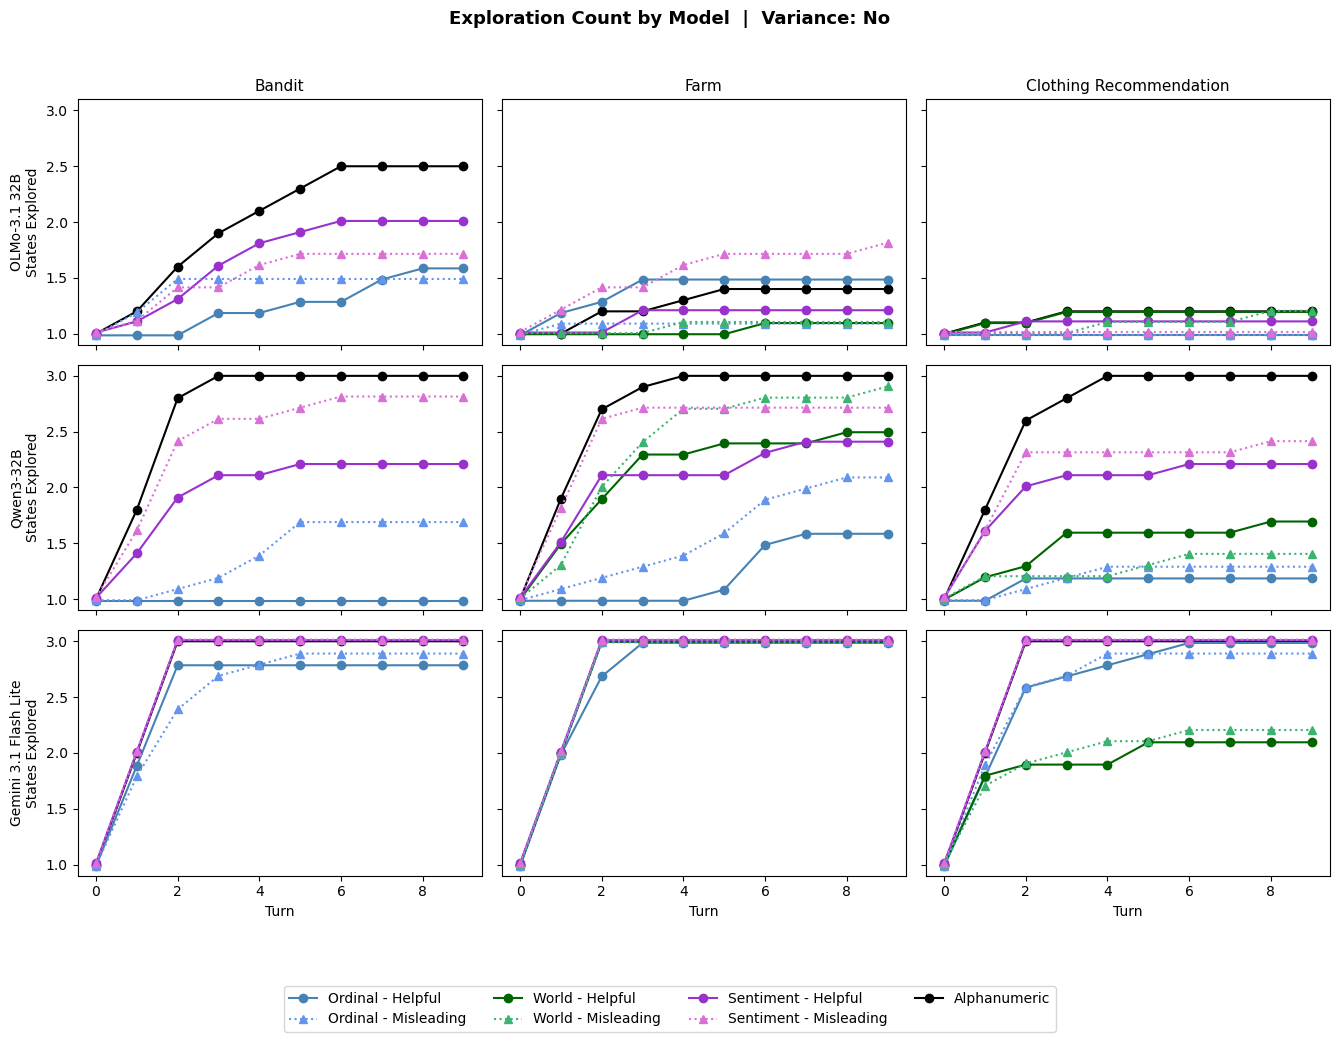

Saved three-model exploration_count: variance=No


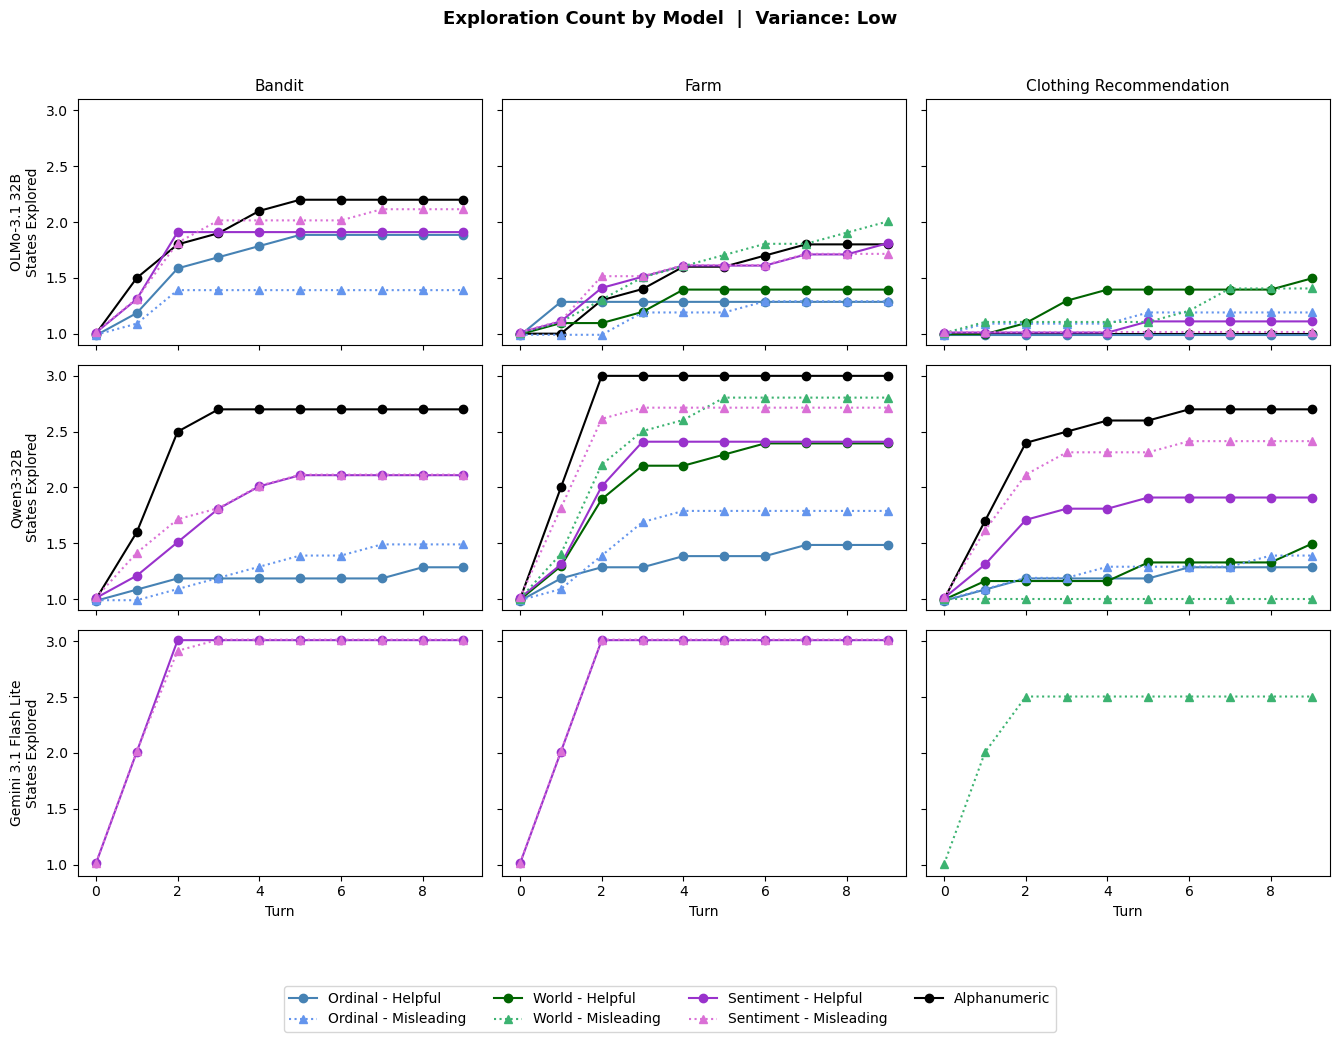

Saved three-model exploration_count: variance=Low


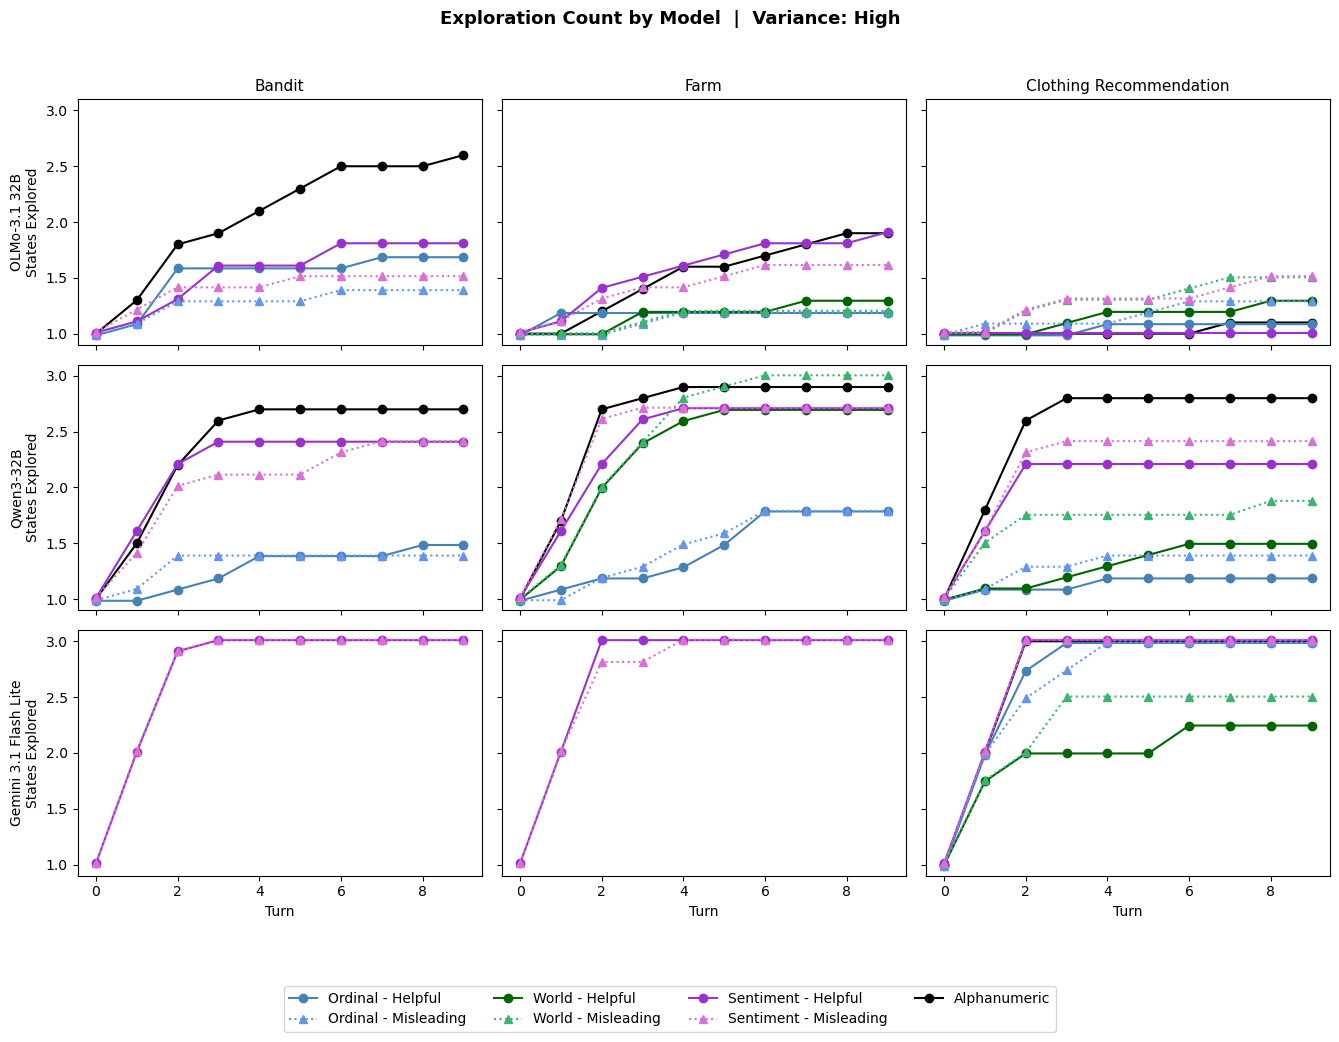

Saved three-model exploration_count: variance=High


In [9]:
THREE_MODELS = [
    ('Olmo-3.1-32B-Instruct',        'OLMo-3.1 32B'),
    ('Qwen3-32B',                     'Qwen3-32B'),
    ('gemini-3.1-flash-lite-preview', 'Gemini 3.1 Flash Lite'),
]

# Variables previously computed in the plotting loop
turn_numbers = sorted(
    int(col.split('_')[-2])
    for col in results_df.columns
    if col.startswith('cum_regret_') and col.endswith('_mean')
)
domains = [d for d in domain_order if d in results_df['domain'].unique()] + \
          [d for d in results_df['domain'].unique() if d not in domain_order]
JITTER_SCALE = {
    'cum_regret':        0.1,
    'exploration_count': 1.0,
}

for variance in all_variances:
    variance_safe = variance.lower()

    # ── Exploration Count: n_models rows × N domains ──
    fig, axes = plt.subplots(
        len(THREE_MODELS), len(domains),
        figsize=(4.5 * len(domains), 3.5 * len(THREE_MODELS)),
        sharex=True, sharey=True,
    )
    if len(domains) == 1:
        axes = axes.reshape(len(THREE_MODELS), 1)

    fig.suptitle(f"Exploration Count by Model  |  Variance: {variance}", fontsize=13, fontweight='bold')

    label_to_handle = {}
    explor_noms = nom_groups['helpful'] + [k for k in nom_groups['mislead'] if k != 'alphanumeric']

    for model_idx, (model, model_label) in enumerate(THREE_MODELS):
        subset = results_df[
            (results_df['model']    == model)   &
            (results_df['history']  == hist)    &
            (results_df['variance'] == variance) &
            (results_df['scale']    == SCALE)
        ]

        for col_idx, domain in enumerate(domains):
            ax = axes[model_idx, col_idx]

            if subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                domain_subset = subset[subset['domain'] == domain]

                for nom_key in explor_noms:
                    nom_df = domain_subset[
                        domain_subset['nomenclature'].str.contains(nom_key, na=False)
                    ]
                    if nom_df.empty:
                        continue

                    means = nom_df[[f"exploration_count_{t}_mean" for t in turn_numbers]].values.flatten()
                    jitter = NOM_Y_JITTER[nom_key] * JITTER_SCALE['exploration_count']
                    means = [y + jitter for y in means]

                    style = NOM_STYLE_MISLEAD_EXPLOR.get(nom_key, NOM_STYLE_CONSTANTS[nom_key])
                    try:
                        handle, = ax.plot(turn_numbers, means, **style)
                        if style['label'] not in label_to_handle:
                            label_to_handle[style['label']] = handle
                    except Exception as e:
                        print(f"ERROR: model={model} domain={domain} nom={nom_key}: {e}")

            if model_idx == len(THREE_MODELS) - 1:
                ax.set_xlabel("Turn")
            if model_idx == 0:
                ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(f"{model_label}\n{metric_map['exploration_count']}", fontsize=10)
            ax.set_ylim(0.9, 3.1)

    explor_legend_order = [
        'ordinal_helpful', 'ordinal_mislead',
        'world_helpful',   'world_mislead',
        'sent_new_helpful', 'sent_new_mislead',
        'alphanumeric',
    ]
    sorted_labels, sorted_handles = [], []
    for k in explor_legend_order:
        style = NOM_STYLE_MISLEAD_EXPLOR.get(k) or NOM_STYLE_CONSTANTS.get(k)
        if style is None:
            continue
        lbl = style['label']
        if lbl in label_to_handle:
            sorted_labels.append(lbl)
            sorted_handles.append(label_to_handle[lbl])

    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=4, borderaxespad=0.5, frameon=True, fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.10, 1, 0.96])

    out_dir     = "figures/exploration_count/three_model_comparison"
    out_dir_png = "figures_png/exploration_count/three_model_comparison"
    os.makedirs(out_dir,     exist_ok=True)
    os.makedirs(out_dir_png, exist_ok=True)
    plt.savefig(f"{out_dir}/variance_{variance_safe}.pdf",     dpi=300, bbox_inches='tight')
    plt.savefig(f"{out_dir_png}/variance_{variance_safe}.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved three-model exploration_count: variance={variance}")